# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 07 — Walk-Forward Research

**Purpose:** evaluate the surviving SuperbCommand architecture sequentially through time, using only information that would have been available before each out-of-sample test period.

Notebook 07 does **not** access the locked 2026 holdout.

The main research question is:

> **If we had repeatedly selected the best surviving SuperbCommand configuration using only prior data, how would that selection have performed in the next unseen year?**

### Candidate SuperbCommand configurations

Notebook 06 leaves four economically defensible candidates:

1. `CORE` + hierarchical equal weight
2. `PT_REDUCE_25` + hierarchical equal weight
3. `CORE` + hierarchical inverse volatility
4. `PT_REDUCE_25` + hierarchical inverse volatility

No oscillator, Bollinger-band, SuperTrend, ATR, standby, or timing hyperparameter is changed here.

### External benchmarks

The fixed Notebook 06 benchmarks remain outside the optimisation set:

- passive long-only;
- 52-week time-series momentum;
- 13/52-week dual-horizon trend.

This prevents a strong benchmark from becoming another in-sample strategy choice.

### Walk-forward structures

Two pre-specified research schemes are tested:

**Rolling 5-year training**
\[
5\text{ years train} \rightarrow 1\text{ year test}
\]

**Expanding training**
\[
\text{all prior history} \rightarrow 1\text{ year test}
\]

The first eligible OOS year is **2011**, after sufficient history has accumulated.

### Model-selection objective

Within each training window, candidates are ranked primarily by:

\[
\text{Sharpe Ratio}
\]

with Calmar ratio used only as a deterministic tie-breaker.

There is no optimisation of the selection metric itself.

### Final holdout discipline

The walk-forward research sample ends at:

**31 December 2025**

The entire 2026 period remains untouched for the later final holdout evaluation.


In [1]:
# ============================================================
# 7.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations

import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 07 cannot run with the final holdout unlocked.")

SC_RETURNS_PATH = PATHS["data_processed"] / "05_portfolio_return_panel.parquet"
BASELINE_RETURNS_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"

for p in [SC_RETURNS_PATH, BASELINE_RETURNS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Walk-forward research ends:", RESEARCH_END.date())
print("Final 2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Walk-forward research ends: 2025-12-31
Final 2026 holdout: LOCKED


In [2]:
# ============================================================
# 7.2 — LOAD RETURNS
# ============================================================
sc_returns = pd.read_parquet(SC_RETURNS_PATH)
baseline_returns = pd.read_parquet(BASELINE_RETURNS_PATH)

if sc_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in SuperbCommand return panel.")

if baseline_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("2026 contamination detected in baseline return panel.")

CANDIDATES = [
    ("CORE", "hier_equal_weight"),
    ("PT_REDUCE_25", "hier_equal_weight"),
    ("CORE", "hier_inverse_vol"),
    ("PT_REDUCE_25", "hier_inverse_vol"),
]

BENCHMARKS = [
    ("PASSIVE_LONG", "hier_equal_weight"),
    ("TSMOM_52W", "hier_equal_weight"),
    ("DUAL_TREND_13_52", "hier_equal_weight"),
    ("PASSIVE_LONG", "hier_inverse_vol"),
    ("TSMOM_52W", "hier_inverse_vol"),
    ("DUAL_TREND_13_52", "hier_inverse_vol"),
]

missing_candidates = [c for c in CANDIDATES if c not in sc_returns.columns]
if missing_candidates:
    raise KeyError(f"Missing candidate return series: {missing_candidates}")

missing_benchmarks = [b for b in BENCHMARKS if b not in baseline_returns.columns]
if missing_benchmarks:
    raise KeyError(f"Missing benchmark return series: {missing_benchmarks}")

candidate_panel = pd.concat(
    {f"{v}__{m}": sc_returns[(v, m)] for v, m in CANDIDATES},
    axis=1
).sort_index()

benchmark_panel = pd.concat(
    {f"{s}__{m}": baseline_returns[(s, m)] for s, m in BENCHMARKS},
    axis=1
).sort_index()

print("Candidate panel:", candidate_panel.shape)
print("Benchmark panel:", benchmark_panel.shape)
display(candidate_panel.tail())


Candidate panel: (1095, 4)
Benchmark panel: (1095, 6)


,CORE__hier_equal_weight,PT_REDUCE_25__hier_equal_weight,CORE__hier_inverse_vol,PT_REDUCE_25__hier_inverse_vol
date,,,,
2025-11-28,0.024878,0.024387,0.008354,0.008029
2025-12-05,-0.003912,-0.004151,-0.002031,-0.002038
2025-12-12,0.000455,0.000592,-0.001748,-0.001721
2025-12-19,-0.001864,-0.002175,0.002072,0.001803
2025-12-26,0.007381,0.006976,0.005022,0.004799


## 7.3 Performance functions

All selection decisions are based on training-window returns only.

No test-period statistic can influence the model selected for that test period.


In [3]:
# ============================================================
# 7.3 — PERFORMANCE FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return float(dd.min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / WEEKS_PER_YEAR
    if years <= 0 or wealth <= 0:
        return np.nan
    return wealth ** (1 / years) - 1

def annualised_vol(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return np.nan
    return float(r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    downside = r[r < 0]
    if len(downside) < 2 or downside.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / downside.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR))

def calmar(r):
    ca = cagr(r)
    md = max_drawdown(r)
    if pd.isna(ca) or pd.isna(md) or md == 0:
        return np.nan
    return float(ca / abs(md))

def metrics(r):
    r = pd.Series(r).dropna()
    return {
        "weeks": len(r),
        "cagr": cagr(r),
        "ann_vol": annualised_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }


## 7.4 Walk-forward schedule

The test unit is one calendar year.

The rolling scheme always uses the five calendar years immediately preceding the test year.

The expanding scheme uses all available history before the test year.

The test years are:

\[
2011, 2012, \ldots, 2025
\]

The 2026 holdout is excluded by construction.


In [4]:
# ============================================================
# 7.4 — DEFINE WALK-FORWARD FOLDS
# ============================================================
FIRST_TEST_YEAR = 2011
LAST_TEST_YEAR = 2025
ROLLING_TRAIN_YEARS = 5

TEST_YEARS = list(range(FIRST_TEST_YEAR, LAST_TEST_YEAR + 1))

def year_slice(df, start_year, end_year):
    return df[
        (df.index.year >= start_year)
        & (df.index.year <= end_year)
    ]

rolling_folds = []
expanding_folds = []

first_data_year = int(candidate_panel.dropna(how="all").index.min().year)

for test_year in TEST_YEARS:
    rolling_folds.append({
        "scheme": "rolling_5y",
        "test_year": test_year,
        "train_start_year": test_year - ROLLING_TRAIN_YEARS,
        "train_end_year": test_year - 1,
    })

    expanding_folds.append({
        "scheme": "expanding",
        "test_year": test_year,
        "train_start_year": first_data_year,
        "train_end_year": test_year - 1,
    })

folds = pd.DataFrame(rolling_folds + expanding_folds)

display(folds.head(10))
print("Total folds:", len(folds))


,scheme,test_year,train_start_year,train_end_year
0,rolling_5y,2011,2006,2010
1,rolling_5y,2012,2007,2011
2,rolling_5y,2013,2008,2012
3,rolling_5y,2014,2009,2013
4,rolling_5y,2015,2010,2014
5,rolling_5y,2016,2011,2015
6,rolling_5y,2017,2012,2016
7,rolling_5y,2018,2013,2017
8,rolling_5y,2019,2014,2018
9,rolling_5y,2020,2015,2019


Total folds: 30


## 7.5 Candidate ranking

Within each training window:

1. calculate training Sharpe and Calmar for every candidate;
2. rank by Sharpe descending;
3. use Calmar only as a tie-breaker;
4. select exactly one candidate;
5. apply that selection unchanged throughout the next calendar year.

This is genuine sequential model selection inside the research sample.


In [5]:
# ============================================================
# 7.5 — WALK-FORWARD SELECTION ENGINE
# ============================================================
selection_rows = []
oos_series = {}

for _, fold in folds.iterrows():
    scheme = fold["scheme"]
    test_year = int(fold["test_year"])
    train_start = int(fold["train_start_year"])
    train_end = int(fold["train_end_year"])

    train = year_slice(candidate_panel, train_start, train_end)
    test = year_slice(candidate_panel, test_year, test_year)

    train_stats = []

    for candidate in candidate_panel.columns:
        m = metrics(train[candidate])

        train_stats.append({
            "candidate": candidate,
            "train_weeks": m["weeks"],
            "train_cagr": m["cagr"],
            "train_sharpe": m["sharpe"],
            "train_calmar": m["calmar"],
            "train_max_drawdown": m["max_drawdown"],
        })

    rank_df = pd.DataFrame(train_stats)

    rank_df["train_sharpe_rank_value"] = rank_df["train_sharpe"].fillna(-np.inf)
    rank_df["train_calmar_rank_value"] = rank_df["train_calmar"].fillna(-np.inf)

    rank_df = rank_df.sort_values(
        ["train_sharpe_rank_value", "train_calmar_rank_value", "candidate"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    selected = rank_df.iloc[0]["candidate"]

    test_return = test[selected].dropna()
    key = (scheme, test_year)
    oos_series[key] = test_return

    test_m = metrics(test_return)

    selection_rows.append({
        "scheme": scheme,
        "test_year": test_year,
        "train_start_year": train_start,
        "train_end_year": train_end,
        "selected_candidate": selected,
        "selected_train_sharpe": rank_df.iloc[0]["train_sharpe"],
        "selected_train_calmar": rank_df.iloc[0]["train_calmar"],
        "test_weeks": test_m["weeks"],
        "test_cagr": test_m["cagr"],
        "test_sharpe": test_m["sharpe"],
        "test_max_drawdown": test_m["max_drawdown"],
    })

selection_history = pd.DataFrame(selection_rows)

display(selection_history.head(20))


,scheme,test_year,train_start_year,train_end_year,selected_candidate,selected_train_sharpe,selected_train_calmar,test_weeks,test_cagr,test_sharpe,test_max_drawdown
0,rolling_5y,2011,2006,2010,PT_REDUCE_25__hier_inverse_vol,0.661298,0.297857,52,0.012508,0.329769,-0.037609
1,rolling_5y,2012,2007,2011,PT_REDUCE_25__hier_inverse_vol,0.650651,0.338412,52,-0.008152,-0.340024,-0.027842
2,rolling_5y,2013,2008,2012,PT_REDUCE_25__hier_inverse_vol,0.433034,0.222852,52,0.002555,0.100905,-0.028417
3,rolling_5y,2014,2009,2013,PT_REDUCE_25__hier_equal_weight,0.693633,0.717321,52,0.010784,0.368200,-0.031027
4,rolling_5y,2015,2010,2014,PT_REDUCE_25__hier_inverse_vol,0.555582,0.397670,52,0.000587,0.033915,-0.046229
5,rolling_5y,2016,2011,2015,CORE__hier_inverse_vol,0.199544,0.124504,53,0.049226,1.447476,-0.023565
6,rolling_5y,2017,2012,2016,CORE__hier_equal_weight,0.562103,0.434524,52,0.957442,3.587032,-0.059726
7,rolling_5y,2018,2013,2017,CORE__hier_equal_weight,1.572298,2.756645,52,-0.130118,-0.844346,-0.169638
8,rolling_5y,2019,2014,2018,CORE__hier_equal_weight,1.099983,0.785230,52,0.191976,1.584063,-0.067342
9,rolling_5y,2020,2015,2019,CORE__hier_inverse_vol,1.433904,1.013802,52,0.081922,1.283191,-0.064346


## 7.6 Stitch annual OOS periods together

The annual out-of-sample returns are concatenated to produce one continuous walk-forward return series for each selection scheme.


In [6]:
# ============================================================
# 7.6 — STITCH OOS RETURNS
# ============================================================
walkforward_returns = {}

for scheme in ["rolling_5y", "expanding"]:
    pieces = []

    for year in TEST_YEARS:
        s = oos_series.get((scheme, year))
        if s is not None and len(s):
            pieces.append(s)

    if pieces:
        walkforward_returns[scheme] = pd.concat(pieces).sort_index()

walkforward_panel = pd.concat(walkforward_returns, axis=1)
walkforward_panel.columns.name = "scheme"

display(walkforward_panel.tail())


scheme,rolling_5y,expanding
date,,
2025-11-28,0.008029,0.008029
2025-12-05,-0.002038,-0.002038
2025-12-12,-0.001721,-0.001721
2025-12-19,0.001803,0.001803
2025-12-26,0.004799,0.004799


## 7.7 Walk-forward performance

These results are more informative than a single full-sample ranking because each yearly return is generated by a choice made using only prior data.


In [7]:
# ============================================================
# 7.7 — WALK-FORWARD PERFORMANCE
# ============================================================
wf_rows = []

for scheme, r in walkforward_returns.items():
    row = {"scheme": scheme}
    row.update(metrics(r))
    wf_rows.append(row)

walkforward_performance = pd.DataFrame(wf_rows).set_index("scheme")

display(walkforward_performance)


,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
scheme,,,,,,,,,
rolling_5y,782,0.082945,0.080795,1.026886,1.440340,-0.169638,0.488952,-0.056229,0.571611
expanding,782,0.067310,0.083910,0.818458,1.099704,-0.179031,0.375970,-0.056237,0.554987


## 7.8 Selection stability

If the chosen specification changes every year, that is evidence of an unstable design choice.

A robust architecture should not require constant switching between superficially similar models.


In [8]:
# ============================================================
# 7.8 — SELECTION FREQUENCY & SWITCHING
# ============================================================
selection_frequency = (
    selection_history
    .groupby(["scheme", "selected_candidate"])
    .size()
    .rename("years_selected")
    .reset_index()
)

display(selection_frequency)

switch_rows = []

for scheme, g in selection_history.sort_values("test_year").groupby("scheme"):
    choices = g["selected_candidate"].tolist()
    switches = sum(a != b for a, b in zip(choices[:-1], choices[1:]))

    switch_rows.append({
        "scheme": scheme,
        "test_years": len(choices),
        "candidate_switches": switches,
        "switch_rate": switches / max(len(choices) - 1, 1),
        "unique_candidates_selected": len(set(choices)),
    })

switch_summary = pd.DataFrame(switch_rows).set_index("scheme")
display(switch_summary)


,scheme,selected_candidate,years_selected
0,expanding,CORE__hier_equal_weight,1
1,expanding,PT_REDUCE_25__hier_equal_weight,5
2,expanding,PT_REDUCE_25__hier_inverse_vol,9
3,rolling_5y,CORE__hier_equal_weight,3
4,rolling_5y,CORE__hier_inverse_vol,2
5,rolling_5y,PT_REDUCE_25__hier_equal_weight,1
6,rolling_5y,PT_REDUCE_25__hier_inverse_vol,9


,test_years,candidate_switches,switch_rate,unique_candidates_selected
scheme,,,,
expanding,15,5,0.357143,3
rolling_5y,15,6,0.428571,4


## 7.9 Candidate-level annual OOS league table

Rather than only studying the dynamically selected model, Notebook 07 also records how each fixed candidate performed in every test year.

This allows us to distinguish:

- a genuinely robust candidate;
- a candidate that wins only because the selector happened to time it well.


In [9]:
# ============================================================
# 7.9 — FIXED-CANDIDATE OOS YEARLY RESULTS
# ============================================================
candidate_oos_rows = []

for test_year in TEST_YEARS:
    test = year_slice(candidate_panel, test_year, test_year)

    for candidate in candidate_panel.columns:
        m = metrics(test[candidate])

        candidate_oos_rows.append({
            "test_year": test_year,
            "candidate": candidate,
            "cagr": m["cagr"],
            "sharpe": m["sharpe"],
            "max_drawdown": m["max_drawdown"],
        })

candidate_oos = pd.DataFrame(candidate_oos_rows)

candidate_oos_summary = (
    candidate_oos
    .groupby("candidate")
    .agg(
        mean_annual_sharpe=("sharpe", "mean"),
        median_annual_sharpe=("sharpe", "median"),
        positive_sharpe_years=("sharpe", lambda x: int((x > 0).sum())),
        years=("test_year", "count"),
        mean_annual_cagr=("cagr", "mean"),
        median_annual_cagr=("cagr", "median"),
    )
    .sort_values("mean_annual_sharpe", ascending=False)
)

candidate_oos_summary["share_positive_sharpe_years"] = (
    candidate_oos_summary["positive_sharpe_years"]
    / candidate_oos_summary["years"]
)

display(candidate_oos_summary)


,mean_annual_sharpe,median_annual_sharpe,positive_sharpe_years,years,mean_annual_cagr,median_annual_cagr,share_positive_sharpe_years
candidate,,,,,,,
PT_REDUCE_25__hier_inverse_vol,1.280557,1.285245,13,15,0.046056,0.049298,0.866667
CORE__hier_inverse_vol,1.277426,1.283191,13,15,0.047064,0.049226,0.866667
PT_REDUCE_25__hier_equal_weight,1.037820,1.236771,11,15,0.155061,0.083860,0.733333
CORE__hier_equal_weight,1.030721,1.185830,12,15,0.155690,0.083493,0.800000


## 7.10 Compare walk-forward SuperbCommand with fixed external benchmarks

The benchmark models remain fixed. They are not selected or tuned inside the walk-forward loop.

The comparison period is restricted to the common 2011–2025 OOS span.


In [10]:
# ============================================================
# 7.10 — WALK-FORWARD VS FIXED BENCHMARKS
# ============================================================
comparison_series = {}

for scheme, r in walkforward_returns.items():
    comparison_series[f"WF_{scheme}"] = r

# Main external references under both surviving weighting methods.
for col in benchmark_panel.columns:
    s = benchmark_panel[col]
    s = s[(s.index.year >= FIRST_TEST_YEAR) & (s.index.year <= LAST_TEST_YEAR)]
    comparison_series[col] = s

comparison = pd.concat(comparison_series, axis=1)

benchmark_perf_rows = []

for name in comparison.columns:
    m = metrics(comparison[name])
    benchmark_perf_rows.append({
        "strategy": name,
        **m,
    })

benchmark_comparison = pd.DataFrame(benchmark_perf_rows).sort_values(
    "sharpe", ascending=False
).reset_index(drop=True)

display(benchmark_comparison)


,strategy,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,worst_week,positive_week_rate
0,DUAL_TREND_13_52__hier_inverse_vol,782,0.045304,0.030892,1.450324,2.092592,-0.040895,1.107815,-0.027334,0.579284
1,TSMOM_52W__hier_inverse_vol,782,0.045705,0.033033,1.370011,1.970963,-0.040466,1.129479,-0.021519,0.586957
2,PASSIVE_LONG__hier_inverse_vol,782,0.054580,0.039569,1.363490,1.802877,-0.069115,0.789700,-0.031262,0.597187
3,DUAL_TREND_13_52__hier_equal_weight,782,0.123604,0.104421,1.169040,1.654016,-0.164009,0.753646,-0.098051,0.569054
4,PASSIVE_LONG__hier_equal_weight,782,0.149082,0.129433,1.139543,1.595200,-0.268229,0.555801,-0.116503,0.562660
5,TSMOM_52W__hier_equal_weight,782,0.123035,0.111186,1.099939,1.530464,-0.176128,0.698558,-0.100519,0.570332
6,WF_rolling_5y,782,0.082945,0.080795,1.026886,1.440340,-0.169638,0.488952,-0.056229,0.571611
7,WF_expanding,782,0.067310,0.083910,0.818458,1.099704,-0.179031,0.375970,-0.056237,0.554987


## 7.11 Relative performance by year

This table shows whether walk-forward SuperbCommand adds value episodically or consistently relative to the strongest fixed benchmark from Notebook 06.


In [11]:
# ============================================================
# 7.11 — YEAR-BY-YEAR COMPARISON TO DUAL TREND / INVERSE VOL
# ============================================================
REFERENCE = "DUAL_TREND_13_52__hier_inverse_vol"

if REFERENCE not in benchmark_panel.columns:
    raise KeyError(f"Reference benchmark not found: {REFERENCE}")

yearly_rows = []

for year in TEST_YEARS:
    ref = benchmark_panel.loc[benchmark_panel.index.year == year, REFERENCE].dropna()
    ref_ret = (1 + ref).prod() - 1 if len(ref) else np.nan

    for scheme, wf in walkforward_returns.items():
        x = wf.loc[wf.index.year == year].dropna()
        wf_ret = (1 + x).prod() - 1 if len(x) else np.nan

        yearly_rows.append({
            "year": year,
            "scheme": scheme,
            "walkforward_return": wf_ret,
            "reference_return": ref_ret,
            "excess_return_vs_reference": (
                wf_ret - ref_ret
                if pd.notna(wf_ret) and pd.notna(ref_ret)
                else np.nan
            ),
        })

yearly_relative = pd.DataFrame(yearly_rows)

display(yearly_relative)


,year,scheme,walkforward_return,reference_return,excess_return_vs_reference
0,2011,rolling_5y,0.012508,0.033153,-0.020645
1,2011,expanding,0.012508,0.033153,-0.020645
2,2012,rolling_5y,-0.008152,-0.002482,-0.005670
3,2012,expanding,-0.008152,-0.002482,-0.005670
4,2013,rolling_5y,0.002555,0.006092,-0.003537
5,2013,expanding,0.002555,0.006092,-0.003537
6,2014,rolling_5y,0.010784,0.027357,-0.016573
7,2014,expanding,0.019220,0.027357,-0.008137
8,2015,rolling_5y,0.000587,0.008969,-0.008383
9,2015,expanding,0.000587,0.008969,-0.008383


## 7.12 Equity curves


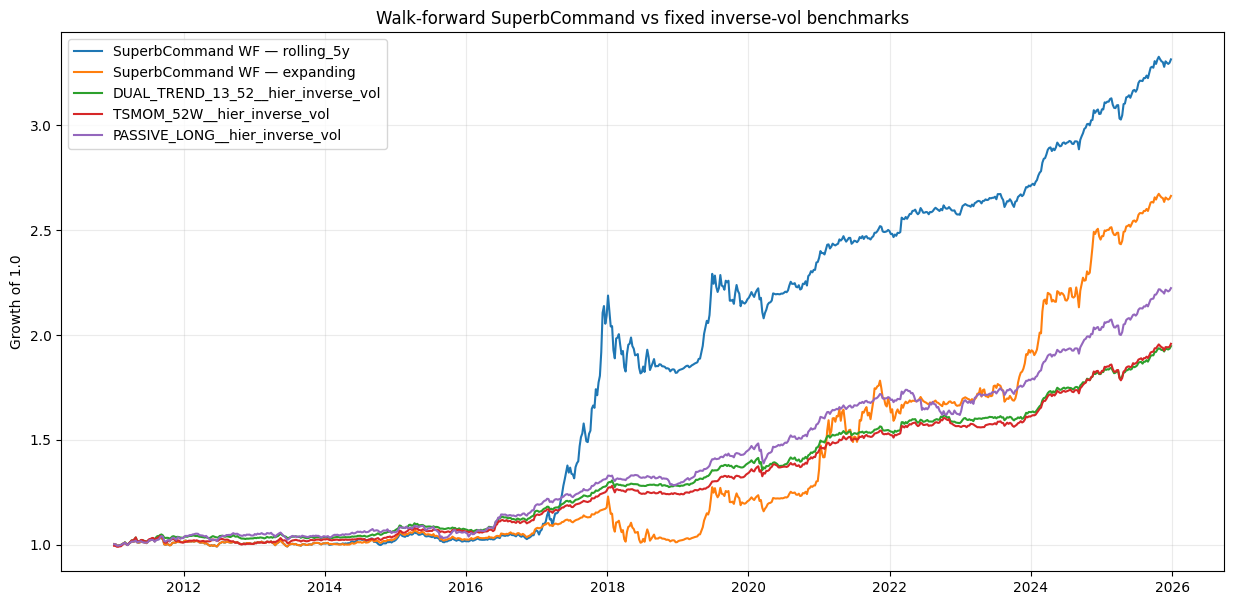

In [12]:
# ============================================================
# 7.12 — WALK-FORWARD EQUITY CURVES
# ============================================================
plt.figure(figsize=(15, 7))

for scheme, r in walkforward_returns.items():
    eq = (1 + r.fillna(0)).cumprod()
    plt.plot(eq.index, eq.values, label=f"SuperbCommand WF — {scheme}")

for ref in [
    "DUAL_TREND_13_52__hier_inverse_vol",
    "TSMOM_52W__hier_inverse_vol",
    "PASSIVE_LONG__hier_inverse_vol",
]:
    if ref in benchmark_panel.columns:
        r = benchmark_panel[ref]
        r = r[(r.index.year >= FIRST_TEST_YEAR) & (r.index.year <= LAST_TEST_YEAR)]
        eq = (1 + r.fillna(0)).cumprod()
        plt.plot(eq.index, eq.values, label=ref)

plt.title("Walk-forward SuperbCommand vs fixed inverse-vol benchmarks")
plt.ylabel("Growth of 1.0")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7.13 Drawdowns


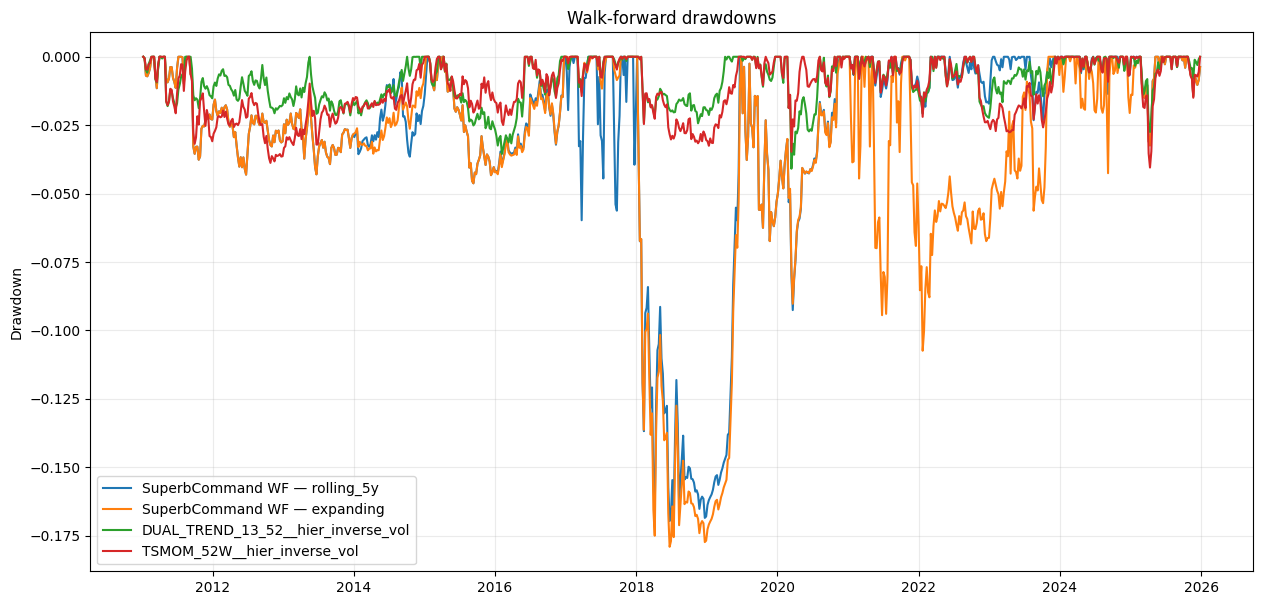

In [13]:
# ============================================================
# 7.13 — WALK-FORWARD DRAWDOWNS
# ============================================================
plt.figure(figsize=(15, 7))

for scheme, r in walkforward_returns.items():
    eq = (1 + r.fillna(0)).cumprod()
    dd = eq / eq.cummax() - 1
    plt.plot(dd.index, dd.values, label=f"SuperbCommand WF — {scheme}")

for ref in [
    "DUAL_TREND_13_52__hier_inverse_vol",
    "TSMOM_52W__hier_inverse_vol",
]:
    if ref in benchmark_panel.columns:
        r = benchmark_panel[ref]
        r = r[(r.index.year >= FIRST_TEST_YEAR) & (r.index.year <= LAST_TEST_YEAR)]
        eq = (1 + r.fillna(0)).cumprod()
        dd = eq / eq.cummax() - 1
        plt.plot(dd.index, dd.values, label=ref)

plt.title("Walk-forward drawdowns")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7.14 Selection map

This is one of the most important diagnostics in Notebook 07.

If the walk-forward optimiser repeatedly flips between candidates, the selection layer may be adding noise rather than robustness.


In [14]:
# ============================================================
# 7.14 — SELECTION MAP
# ============================================================
selection_map = selection_history.pivot(
    index="test_year",
    columns="scheme",
    values="selected_candidate",
)

display(selection_map)


scheme,expanding,rolling_5y
test_year,,
2011,PT_REDUCE_25__hier_inverse_vol,PT_REDUCE_25__hier_inverse_vol
2012,PT_REDUCE_25__hier_inverse_vol,PT_REDUCE_25__hier_inverse_vol
2013,PT_REDUCE_25__hier_inverse_vol,PT_REDUCE_25__hier_inverse_vol
2014,PT_REDUCE_25__hier_inverse_vol,PT_REDUCE_25__hier_equal_weight
2015,PT_REDUCE_25__hier_inverse_vol,PT_REDUCE_25__hier_inverse_vol
2016,PT_REDUCE_25__hier_inverse_vol,CORE__hier_inverse_vol
2017,PT_REDUCE_25__hier_inverse_vol,CORE__hier_equal_weight
2018,PT_REDUCE_25__hier_equal_weight,CORE__hier_equal_weight
2019,CORE__hier_equal_weight,CORE__hier_equal_weight


## 7.15 Stress-period OOS behaviour

Only stress periods that fall within the 2011–2025 walk-forward test range are shown.

The GFC is excluded from this section because it occurs before the OOS walk-forward period begins.


In [15]:
# ============================================================
# 7.15 — OOS STRESS PERIODS
# ============================================================
OOS_STRESS_PERIODS = {
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in OOS_STRESS_PERIODS.items():
    for scheme, r in walkforward_returns.items():
        x = r.loc[start:end].dropna()

        if len(x):
            stress_rows.append({
                "period": period,
                "strategy": f"WF_{scheme}",
                "weeks": len(x),
                "total_return": (1 + x).prod() - 1,
                "max_drawdown": max_drawdown(x),
                "worst_week": x.min(),
            })

    for ref in [
        "DUAL_TREND_13_52__hier_inverse_vol",
        "TSMOM_52W__hier_inverse_vol",
        "PASSIVE_LONG__hier_inverse_vol",
    ]:
        if ref in benchmark_panel.columns:
            x = benchmark_panel.loc[start:end, ref].dropna()

            if len(x):
                stress_rows.append({
                    "period": period,
                    "strategy": ref,
                    "weeks": len(x),
                    "total_return": (1 + x).prod() - 1,
                    "max_drawdown": max_drawdown(x),
                    "worst_week": x.min(),
                })

stress_oos = pd.DataFrame(stress_rows)
display(stress_oos)


,period,strategy,weeks,total_return,max_drawdown,worst_week
0,Euro-area stress,WF_rolling_5y,65,-0.008064,-0.043045,-0.026096
1,Euro-area stress,WF_expanding,65,-0.008064,-0.043045,-0.026096
2,Euro-area stress,DUAL_TREND_13_52__hier_inverse_vol,65,0.004813,-0.018759,-0.016361
3,Euro-area stress,TSMOM_52W__hier_inverse_vol,65,-0.009795,-0.031804,-0.019208
4,Euro-area stress,PASSIVE_LONG__hier_inverse_vol,65,0.022282,-0.033990,-0.019343
5,COVID crash,WF_rolling_5y,12,-0.011588,-0.064346,-0.031292
6,COVID crash,WF_expanding,12,-0.010910,-0.062084,-0.030534
7,COVID crash,DUAL_TREND_13_52__hier_inverse_vol,12,-0.002513,-0.040895,-0.027334
8,COVID crash,TSMOM_52W__hier_inverse_vol,12,0.012525,-0.034710,-0.021114
9,COVID crash,PASSIVE_LONG__hier_inverse_vol,12,-0.011276,-0.064176,-0.031262


## 7.16 Walk-forward interpretation aids

The purpose of the following diagnostics is to distinguish three possible outcomes:

### A. Stable candidate dominance
One candidate is repeatedly selected and performs well OOS.

This suggests the architecture may be robust enough to simplify further.

### B. Frequent model switching with no OOS benefit
The selector changes often but fails to beat a fixed candidate.

This suggests model-selection noise.

### C. SuperbCommand remains behind simple trend benchmarks
This does **not** justify tuning toward the benchmark inside the same sample.

It would mean the benchmark remains the stronger pre-holdout model and SuperbCommand's role should be reconsidered or studied as a complementary signal only after the validation framework is complete.


In [16]:
# ============================================================
# 7.16 — SIMPLE WALK-FORWARD DIAGNOSTIC SUMMARY
# ============================================================
diagnostic_rows = []

for scheme in ["rolling_5y", "expanding"]:
    wf = walkforward_returns[scheme]
    wf_m = metrics(wf)

    ref = benchmark_panel[REFERENCE]
    ref = ref[(ref.index >= wf.index.min()) & (ref.index <= wf.index.max())]
    common = pd.concat([wf.rename("wf"), ref.rename("ref")], axis=1).dropna()

    wf_common = metrics(common["wf"])
    ref_common = metrics(common["ref"])

    sel = switch_summary.loc[scheme]

    diagnostic_rows.append({
        "scheme": scheme,
        "oos_start": wf.index.min(),
        "oos_end": wf.index.max(),
        "oos_sharpe": wf_m["sharpe"],
        "oos_cagr": wf_m["cagr"],
        "oos_max_drawdown": wf_m["max_drawdown"],
        "dual_trend_invvol_sharpe_same_period": ref_common["sharpe"],
        "sharpe_gap_vs_dual_trend": wf_common["sharpe"] - ref_common["sharpe"],
        "candidate_switches": sel["candidate_switches"],
        "switch_rate": sel["switch_rate"],
        "unique_candidates_selected": sel["unique_candidates_selected"],
    })

diagnostic_summary = pd.DataFrame(diagnostic_rows).set_index("scheme")
display(diagnostic_summary)


,oos_start,oos_end,oos_sharpe,oos_cagr,oos_max_drawdown,dual_trend_invvol_sharpe_same_period,sharpe_gap_vs_dual_trend,candidate_switches,switch_rate,unique_candidates_selected
scheme,,,,,,,,,,
rolling_5y,2011-01-07,2025-12-26,1.026886,0.082945,-0.169638,1.450324,-0.423438,6.0,0.428571,4.0
expanding,2011-01-07,2025-12-26,0.818458,0.067310,-0.179031,1.450324,-0.631866,5.0,0.357143,3.0


## 7.17 Save outputs


In [17]:
# ============================================================
# 7.17 — SAVE OUTPUTS
# ============================================================
SELECTION_PATH = PATHS["results"] / "07_walk_forward_selection_history.csv"
WF_PERF_PATH = PATHS["results"] / "07_walk_forward_performance.csv"
SWITCH_PATH = PATHS["results"] / "07_walk_forward_switch_summary.csv"
CANDIDATE_OOS_PATH = PATHS["results"] / "07_candidate_oos_summary.csv"
BENCHMARK_PATH = PATHS["results"] / "07_walk_forward_benchmark_comparison.csv"
YEARLY_RELATIVE_PATH = PATHS["results"] / "07_yearly_relative_vs_dual_trend.csv"
STRESS_PATH = PATHS["results"] / "07_walk_forward_stress_summary.csv"
DIAGNOSTIC_PATH = PATHS["results"] / "07_walk_forward_diagnostic_summary.csv"

WF_RETURNS_PATH = PATHS["data_processed"] / "07_walk_forward_return_panel.parquet"

selection_history.to_csv(SELECTION_PATH, index=False)
walkforward_performance.to_csv(WF_PERF_PATH)
switch_summary.to_csv(SWITCH_PATH)
candidate_oos_summary.to_csv(CANDIDATE_OOS_PATH)
benchmark_comparison.to_csv(BENCHMARK_PATH, index=False)
yearly_relative.to_csv(YEARLY_RELATIVE_PATH, index=False)
stress_oos.to_csv(STRESS_PATH, index=False)
diagnostic_summary.to_csv(DIAGNOSTIC_PATH)

walkforward_panel.to_parquet(WF_RETURNS_PATH)

print("Saved Notebook 07 outputs.")


Saved Notebook 07 outputs.


## 7.18 Validation suite

Notebook 07 passes only if:

- 2026 is absent;
- every test year from 2011 through 2025 is present;
- every fold selects exactly one candidate;
- the selected candidate is always from the pre-declared four-candidate set;
- rolling training windows are exactly five years;
- test returns occur strictly after their corresponding training window;
- output files are written successfully.


In [18]:
# ============================================================
# 7.18 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = walkforward_panel.index.max() <= RESEARCH_END
checks["2026_absent"] = not (walkforward_panel.index.year == 2026).any()

expected_years = set(TEST_YEARS)

for scheme in ["rolling_5y", "expanding"]:
    actual_years = set(
        selection_history.loc[
            selection_history["scheme"] == scheme,
            "test_year"
        ].astype(int)
    )
    checks[f"{scheme}_all_test_years_present"] = actual_years == expected_years

candidate_names = set(candidate_panel.columns)

checks["all_selections_from_candidate_set"] = set(
    selection_history["selected_candidate"]
).issubset(candidate_names)

checks["one_selection_per_fold"] = (
    selection_history.groupby(["scheme", "test_year"]).size().eq(1).all()
)

rolling = selection_history[selection_history["scheme"] == "rolling_5y"]
checks["rolling_training_exactly_5y"] = (
    (rolling["train_end_year"] - rolling["train_start_year"] + 1) == 5
).all()

checks["train_precedes_test"] = (
    selection_history["train_end_year"]
    < selection_history["test_year"]
).all()

checks["walkforward_series_nonempty"] = all(
    len(r) > 0 for r in walkforward_returns.values()
)

checks["output_files_written"] = all(
    p.exists()
    for p in [
        SELECTION_PATH,
        WF_PERF_PATH,
        SWITCH_PATH,
        CANDIDATE_OOS_PATH,
        BENCHMARK_PATH,
        YEARLY_RELATIVE_PATH,
        STRESS_PATH,
        DIAGNOSTIC_PATH,
        WF_RETURNS_PATH,
    ]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 07 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 07 STATUS: PASS")
print("=" * 78)
print("Sequential walk-forward research completed.")
print("No signal hyperparameters were optimised.")
print("The 2026 final holdout remains untouched.")
print("Review the OOS results before proceeding.")


                            check  passed
                   holdout_absent    True
                      2026_absent    True
rolling_5y_all_test_years_present    True
 expanding_all_test_years_present    True
all_selections_from_candidate_set    True
           one_selection_per_fold    True
      rolling_training_exactly_5y    True
              train_precedes_test    True
      walkforward_series_nonempty    True
             output_files_written    True

NOTEBOOK 07 STATUS: PASS
Sequential walk-forward research completed.
No signal hyperparameters were optimised.
The 2026 final holdout remains untouched.
Review the OOS results before proceeding.


In [19]:
# ============================================================
# 7.19 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "07",
    "notebook_name": "Walk-Forward Research",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_start": str(HOLDOUT_START.date()),
    "holdout_accessed": False,
    "candidate_set": list(candidate_panel.columns),
    "benchmark_set": list(benchmark_panel.columns),
    "walk_forward_schemes": {
        "rolling_5y": {
            "training_years": 5,
            "test_years": 1,
        },
        "expanding": {
            "training": "all prior available history",
            "test_years": 1,
        },
    },
    "first_test_year": FIRST_TEST_YEAR,
    "last_test_year": LAST_TEST_YEAR,
    "selection_objective": "Sharpe ratio; Calmar deterministic tie-breaker",
    "signal_hyperparameters_optimised": False,
    "outputs": {
        "selection_history": str(SELECTION_PATH),
        "walk_forward_performance": str(WF_PERF_PATH),
        "switch_summary": str(SWITCH_PATH),
        "candidate_oos_summary": str(CANDIDATE_OOS_PATH),
        "benchmark_comparison": str(BENCHMARK_PATH),
        "yearly_relative_vs_dual_trend": str(YEARLY_RELATIVE_PATH),
        "stress_summary": str(STRESS_PATH),
        "diagnostic_summary": str(DIAGNOSTIC_PATH),
        "walk_forward_return_panel": str(WF_RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "07_walk_forward_research_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/07_walk_forward_research_manifest.json


---

# End of Notebook 07

## What Notebook 07 establishes

Notebook 07 tests whether model selection among the surviving SuperbCommand variants is stable and useful when performed **strictly sequentially**.

The principal outputs are:

- annual selected candidate;
- continuous rolling-window OOS performance;
- continuous expanding-window OOS performance;
- model-switching frequency;
- fixed-candidate OOS consistency;
- comparison with the fixed 13/52 trend benchmark;
- OOS stress-period behaviour.

### Important

The **2026 final holdout has still not been accessed**.

Do not unlock 2026 merely because one walk-forward configuration looks attractive.

Review the walk-forward evidence first, then determine the next research step.
